<a href="https://colab.research.google.com/github/jennatieby/Instacart-Customer-Analytics/blob/main/Final_Customer_Analytics_InstaCart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🛒 Instacart Recommender System: Predicting Reorders & Bundling Products**

**Introduction**

> With the growth of e-commerce and on-demand delivery platforms, understanding customer purchase behavior is more important than ever. Retailers are increasingly expected to provide personalized, timely recommendations that align with users’ shopping habits. This project explores consumer behavior within the Instacart platform using transaction-level data from over 3 million grocery orders.

> The goal is to build a data-driven recommender system that not only predicts which products a user is likely to reorder, but also identifies combinations of products frequently purchased together. By analyzing individual behavior and uncovering broader shopping patterns, we aim to help retailers personalize the customer experience, improve retention, and drive cross-sell opportunities.


**InstaCart Online Grocery Dataset Description:**

> The Instacart dataset captured over 3 million orders placed by more than 200,000 users on a popular online grocery platform. In this system, users select items through an app, and personal shoppers fulfill and deliver the orders.

> The dataset includes detailed transactional data, such as user purchase histories, order timing, and product-level information. It provides an opportunity to explore how people shop over time—what they tend to reorder, which products are commonly bought together, and how their habits vary by day or season.



**Acknowledgements:**
> Dataset source: [Instacart Market Basket Analysis - Kaggle](https://www.kaggle.com/c/instacart-market-basket-analysis/data)


**Focus:**
> **How can we help retailers recommend the right products at the right time?**


**Objective:**

> Build a recommender system using consumer purchase patterns to:  
- Predict reorders  
- Suggest personalized product bundles

## **Loading Dataset & Preprocessing**

### **Kaggle Dataset API Setup**

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jennatieby","key":"db5fa0bccf38de986aa6e29f3635c0cc"}'}

In [3]:
!pip install kaggle
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
# downloading the dataset using the Kaggle API
!kaggle datasets download -d yasserh/instacart-online-grocery-basket-analysis-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserh/instacart-online-grocery-basket-analysis-dataset
License(s): CC0-1.0


In [5]:
# unzip the dataset
!unzip instacart-online-grocery-basket-analysis-dataset.zip -d instacart_data

Archive:  instacart-online-grocery-basket-analysis-dataset.zip
  inflating: instacart_data/aisles.csv  
  inflating: instacart_data/departments.csv  
  inflating: instacart_data/order_products__prior.csv  
  inflating: instacart_data/order_products__train.csv  
  inflating: instacart_data/orders.csv  
  inflating: instacart_data/products.csv  


### **Reading CSV Files**

In [6]:
import pandas as pd

In [7]:
aisles = pd.read_csv('instacart_data/aisles.csv')
departments = pd.read_csv('instacart_data/departments.csv')
order_products_prior = pd.read_csv('instacart_data/order_products__prior.csv')
order_products_train = pd.read_csv('instacart_data/order_products__train.csv')
orders = pd.read_csv('instacart_data/orders.csv')
products = pd.read_csv('instacart_data/products.csv')

In [8]:
print("aisles:", aisles.shape)
print("departments:", departments.shape)
print("order_products_prior:", order_products_prior.shape)
print("order_products_train:", order_products_train.shape)
print("orders:", orders.shape)
print("products:", products.shape)

aisles: (134, 2)
departments: (21, 2)
order_products_prior: (32434489, 4)
order_products_train: (1384617, 4)
orders: (3421083, 7)
products: (49688, 4)


In [9]:
aisles.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [10]:
departments.head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [11]:
order_products_prior.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [12]:
order_products_train.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [13]:
orders.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [14]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


### **Merging Datasets**

> The Instacart dataset is split across multiple tables, each containing part of the picture: products, orders, users, and transactions. The goal of merging is to combine these pieces into a single, enriched dataset that provides what products were ordered, who ordered them, when they were ordered, product category context (aisle and department), whether or not the product was reordered





> **What** was merged:
*   products
*   aisles (via aisle_id)
*   departments (via department_id)

> **How**:
*   Merge products with aisles on aisle_id
*   Merge result with departments on department_id

>**Why**:
The products table only contains IDs for aisle and department. To analyze or model product preferences, we need human-readable labels (e.g., “snacks”, “beverages”) which come from aisles and departments. This merge adds contextual categories to each product.

In [15]:
product_details = products.merge(aisles, on='aisle_id') \
                          .merge(departments, on='department_id')

In [16]:
product_details.head()

,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen meals,frozen
4,5,Green Chile Anytime Sauce,5,13,marinades meat preparation,pantry


> **What** was merged:
*   order_products__prior (order-item records)
*   product_details (enriched product info from step 2)

>**How:** Merge on product_id

>**Why:**
The order_products__prior table tells us what product was ordered, but not what the product is.
By merging with product_details, we get product names and categories (aisle/department), which are essential for product-level insights and grouping in market basket analysis.

In [17]:
prior_merged = order_products_prior.merge(product_details, on='product_id')

In [18]:
prior_merged.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


> **What** was merged:
*   prior_merged (product-level transactions)
*   orders (order-level metadata: user, time, etc.)

> **How:** Merge on order_id

>**Why:** Each row in prior_merged shows a user buying a product, but lacks user info or order context.


In [19]:
prior_full = prior_merged.merge(orders, on='order_id')

In [20]:
prior_full.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8.0


In [21]:
prior_full.to_parquet("prior_full.parquet")

## **Data Cleaning**

In [22]:
import pandas as pd
prior_full = pd.read_parquet("prior_full.parquet")

In [23]:
prior_full.head(5)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8.0


### **Duplicates**

> Having duplicate rows in a dataset can lead to inaccurate analysis and misleading results. Duplicates can artificially inflate counts, skew averages, and distort patterns, especially in metrics like total sales, number of purchases, or customer behavior. In this case there are none, so no rows need to be removed.

In [24]:
prior_full.duplicated().sum()

np.int64(0)

### **Missing Values**

> The dataset contains **missing values** in the days_since_prior_order column — around 2,078,068 in total, which accounts for approximately 6% of all rows. These missing values are likely due to new customers placing their first-ever order, meaning there’s no previous order to calculate the number of days since. It’s also possible that the date of a prior order simply isn’t available. Since the dataset doesn’t include any actual date columns (like specific timestamps or calendar dates), we currently don’t have a way to calculate the number of days between orders ourselves. Because of this, a deeper analysis will be conducted to explore whether there are any noticeable patterns in the rows with missing days_since_prior_order values. The goal is to decide on the best way to handle these — whether that means filling them in with a default value or removing them entirely from the dataset.

In [25]:
prior_full.isna().sum()

,0
order_id,0
product_id,0
add_to_cart_order,0
reordered,0
product_name,0
aisle_id,0
department_id,0
aisle,0
department,0
user_id,0


> To investigate the **nature of the missing values** in the days_since_prior_order column, we segmented the dataset into two groups:
*   rows with missing values
*   rows with valid (non-null) in that column

> We then compared key characteristics across these two groups to determine whether the rows with missing values followed a similar pattern to the rest of the data or if they represented a distinct use case that required special handling. Our analysis revealed three critical findings.

>First, the reordered rate was 0% among rows with missing values, compared to 63% among rows with valid values, indicating that none of the users had ordered these products before.Second, the mean order_number for rows with missing values was exactly 1.0, while the rest of the data had a mean order number of approximately 18.25. This confirms that every row with a missing days_since_prior_order corresponds to a user's first-ever purchase on the platform. Since there is no "prior" order for these cases, it's logical that the column is missing — because the concept of "days since previous order" doesn't apply.

>Additionally, the product distribution and order time (both order_hour_of_day and order_dow) were consistent between the two groups, suggesting that apart from being first orders, the behavior was similar. Based on this analysis, we concluded that the missing values are not a result of data entry error or irregular behavior, but rather an expected consequence of the dataset's structure.To impute these values in a meaningful and conservative manner, we chose to fill them with a value of 30 — a reasonable estimate representing a longer gap (i.e., over a month) since there is no earlier order. This avoids artificially inflating activity metrics (which filling with 0 would do), while still preserving the rows for further analysis or modeling. The imputation was performed specifically on rows where order_number equals 1, ensuring that only true first-time purchases were affected.

In [26]:
# Create the two groups
has_value = prior_full[prior_full['days_since_prior_order'].notnull()]
missing_value = prior_full[prior_full['days_since_prior_order'].isnull()]

# Reorder rate
print("Mean reordered rate:")
print("Has value:", has_value['reordered'].mean())
print("Missing value:", missing_value['reordered'].mean())

# Order hour comparison
print("\nMean order_hour_of_day:")
print("Has value:", has_value['order_hour_of_day'].mean())
print("Missing value:", missing_value['order_hour_of_day'].mean())

# Order number comparison
print("\nMean order_number:")
print("Has value:", has_value['order_number'].mean())
print("Missing value:", missing_value['order_number'].mean())

# Top products comparison
print("\nTop product names (missing values):")
print(missing_value['product_name'].value_counts().head())

print("\nTop product names (has values):")
print(has_value['product_name'].value_counts().head())

Mean reordered rate:
Has value: 0.6300655798652944
Missing value: 0.0

Mean order_hour_of_day:
Has value: 13.411245515405126
Missing value: 13.625572887893947

Mean order_number:
Has value: 18.247064467843558
Missing value: 1.0

Top product names (missing values):
product_name
Banana                    29534
Bag of Organic Bananas    19158
Organic Strawberries      16464
Organic Avocado           15187
Organic Baby Spinach      14948
Name: count, dtype: int64

Top product names (has values):
product_name
Banana                    443031
Bag of Organic Bananas    360292
Organic Strawberries      248219
Organic Baby Spinach      226973
Organic Hass Avocado      202478
Name: count, dtype: int64


In [27]:
# Fill missing values in the days_since_prior_order column with 30
prior_full['days_since_prior_order'] = prior_full['days_since_prior_order'].fillna(30)

### **Data Types**

> Changing the **data types of columns** in a dataset is a crucial step in data cleaning and optimization. When a column that stores text data, such as product names or department labels, is labeled as an object in pandas, it can lead to inefficiencies and inconsistent behavior during analysis. Converting these columns to the **string dtype** ensures more reliable string operations, better performance, and cleaner integration with pandas' built-in text-handling tools.

> Similarly, when dealing with **numeric data** like days_since_prior_order, it's important to store the values in the most appropriate numeric type. If this column is stored as a float but the values represent whole numbers (i.e., complete days), converting it to an **int type** makes the data cleaner, more intuitive, and semantically accurate. It also helps prevent logical errors in downstream analysis — for example, avoiding confusion between 7 days and 7.0 days. Additionally, using the correct data type can reduce memory usage and improve computational efficiency, especially in large datasets. Overall, making these conversions reflects the true nature of the data and supports both clarity and performance in analysis.

In [28]:
prior_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 15 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   product_id              int64  
 2   add_to_cart_order       int64  
 3   reordered               int64  
 4   product_name            object 
 5   aisle_id                int64  
 6   department_id           int64  
 7   aisle                   object 
 8   department              object 
 9   user_id                 int64  
 10  eval_set                object 
 11  order_number            int64  
 12  order_dow               int64  
 13  order_hour_of_day       int64  
 14  days_since_prior_order  float64
dtypes: float64(1), int64(10), object(4)
memory usage: 3.6+ GB


In [29]:
prior_full['product_name'] = prior_full['product_name'].astype("string")
prior_full['aisle'] = prior_full['aisle'].astype("string")
prior_full['department'] = prior_full['department'].astype("string")
prior_full['eval_set'] = prior_full['eval_set'].astype("string")
prior_full['days_since_prior_order'] = prior_full['days_since_prior_order'].astype(int)

### **Cleaned Dataset**

In [30]:
# Save the cleaned data
prior_full.to_parquet("cleaned_full_instacart.parquet")

## **Exploratory Data Analysis**

**Methodology:**
> The goal of this exploratory data analysis (EDA) was to uncover meaningful patterns, trends, and anomalies in the Instacart dataset that inform customer behavior, product performance, and operational insights. The analysis was structured around three core pillars: **user behavior**, **product performance**, and **temporal ordering patterns**.

> To explore **customer purchase behavior**, visualizations were created to examine the distribution of reordered versus non-reordered items, the frequency of repeat purchases by department, and the time intervals between orders per user. These revealed high reorder rates for departments like dairy and produce, along with weekly and bi-weekly shopping patterns among the majority of users.

> **Product analysis** focused on identifying the most frequently ordered products, aisles, and departments. Bar charts and histograms were used to visualize order volume and reorder propensity across categories, highlighting staple products like bananas, organic spinach, and milk.

> **Temporal patterns** were assessed through plots of orders by day of week and hour of day, revealing peak ordering activity on Sundays and during late mornings to early afternoons.

> Finally, **basket-level** insights were derived by analyzing the number of unique items per order. This revealed that most customers purchase between 5 and 15 items per trip, suggesting a prevalence of top-up shopping behavior.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')
cleaned_df= pd.read_parquet('cleaned_full_instacart.parquet')

In [32]:
cleaned_df.head(10)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8
5,2,17794,6,1,Carrots,83,4,fresh vegetables,produce,202279,prior,3,5,9,8
6,2,40141,7,1,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry,202279,prior,3,5,9,8
7,2,1819,8,1,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry,202279,prior,3,5,9,8
8,2,43668,9,0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce,202279,prior,3,5,9,8
9,3,33754,1,1,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs,205970,prior,16,5,17,12


### **Product Popularity**

> This bar chart highlights the **top 10 most frequently ordered products** across all users in the Instacart dataset. The most ordered item by far is **Bananas**, followed by other staple fruits and vegetables such as Bag of Organic Bananas, Organic Strawberries, and Organic Baby Spinach.

> Several trends are notable here:
*   **Fresh produce** are highly ranked, suggesting strong consumer preference for recurring purchases of healthy staples.
*   **Organic products** make up the majority of the list, reflecting either a health conscious customer base or that instacart as a retailer has a strong organic product offering.



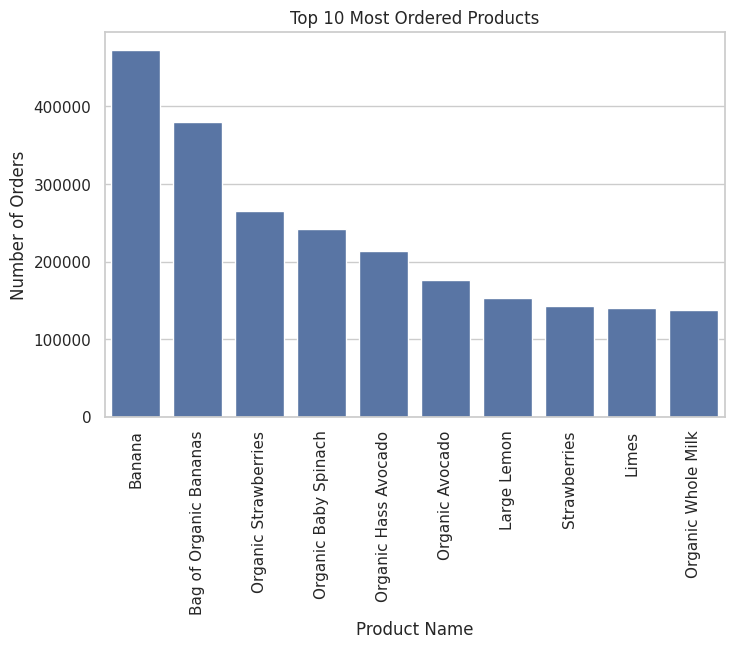

In [33]:
# Explore product popularity through the top 10 most ordered products
product_counts = cleaned_df['product_name'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=product_counts.index, y=product_counts.values)
plt.xticks(rotation=90)
plt.title('Top 10 Most Ordered Products')
plt.xlabel('Product Name')
plt.ylabel('Number of Orders')
plt.show()

### **Orders per Day of Week**

> This bar chart shows the distribution of orders placed across each day of the week on the Instacart platform. We can see a very clear weekly pattern where **Sunday and Monday are the peak days for online grocery orders**, with Sunday exceeding 6 million orders. From this we can conclude that many customers prefer to restock their groceries at the start of the week.

> **Midweek days like Wednesday and Thursday have the lowest order volumes**, which could be due to many factors such as busier schedules. Then we can see that sales volumes increase on **Friday and Saturday which may reflect last-minute weekend shopping**.



<ipython-input-34-fedd601d0a47>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(day_labels)


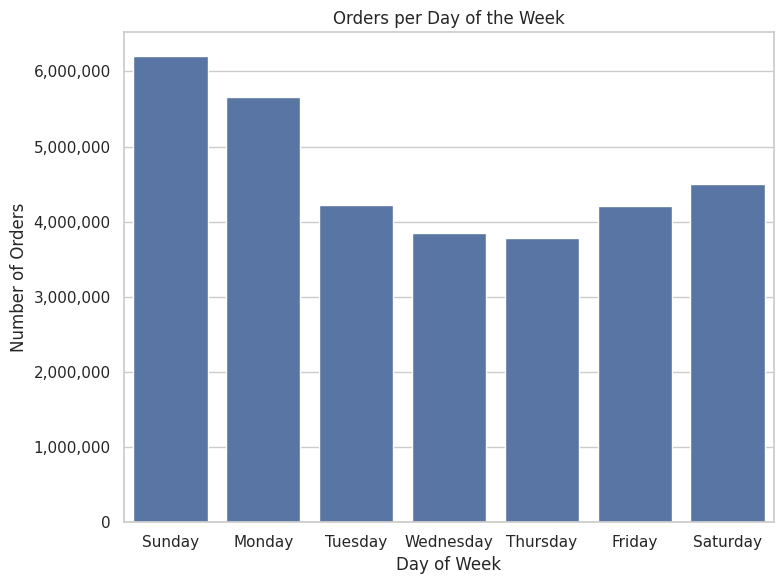

In [34]:
# Analyze order patterns per day of the week
from matplotlib.ticker import FuncFormatter
day_labels = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='order_dow', data=cleaned_df)

ax.set_xticklabels(day_labels)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title('Orders per Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### **Orders per Hour of Day**


> This chart shows when customers are most active on the Instacart platform throughout the day. The volume of orders **increases heavily from 7 AM**, **peaking between 10 AM and 3 PM**, with the highest order volume taking place around **11 AM**. This trend suggests that customers typically place their grocery orders during the late morning and early afternoon.

> On the other hand we can see that order activity is significantly lower during **overnight and early morning hours (midnight to 6 AM)**, which is expected given the fact that most people are asleep during those times. **Evening activity decreases steadily after 4 PM**, possibly because many customers prefer to place orders earlier in the day for same-day or next-day delivery.





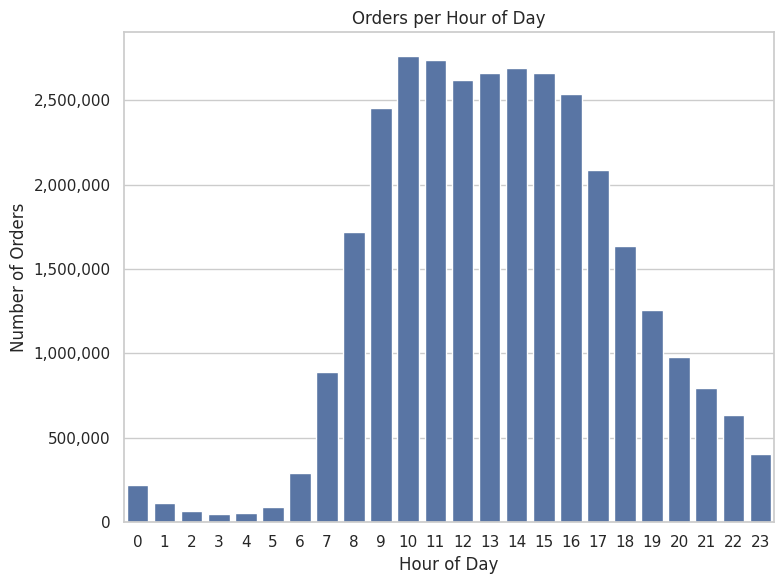

In [35]:
# Analyze order patterns per hour of day
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='order_hour_of_day', data=cleaned_df)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title('Orders per Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

### **Top 10 Aisles**

> The chart showcases the top 10 aisles by total number of orders. **Fresh fruits** and **fresh vegetables** are ranked much higher than other aisles by a significant margin, with over **3.6 million **and **3.4 million **orders respectively. This indicates that customers heavily rely on Instacart for frequent grocery staples particularly in the produce category.

> Beyond fresh items, **packaged vegetables and fruits**, **yogurt**, and **dairy products** like cheese and milk are also top performers. Their presence suggests that many consumers use the platform for a mix of both perishable essentials and convenient refrigerated goods.

> Additionally, categories such as **sparkling water**, **snacks** (chips & pretzels), and **soy/lactose-free **alternatives highlight niche but consistent demand in beverages and dietary-specific items.


 Top 10 Aisles:
aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
Name: count, dtype: Int64


<ipython-input-36-ee9f41c68f34>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_aisles.values, y=top_aisles.index, palette='crest')


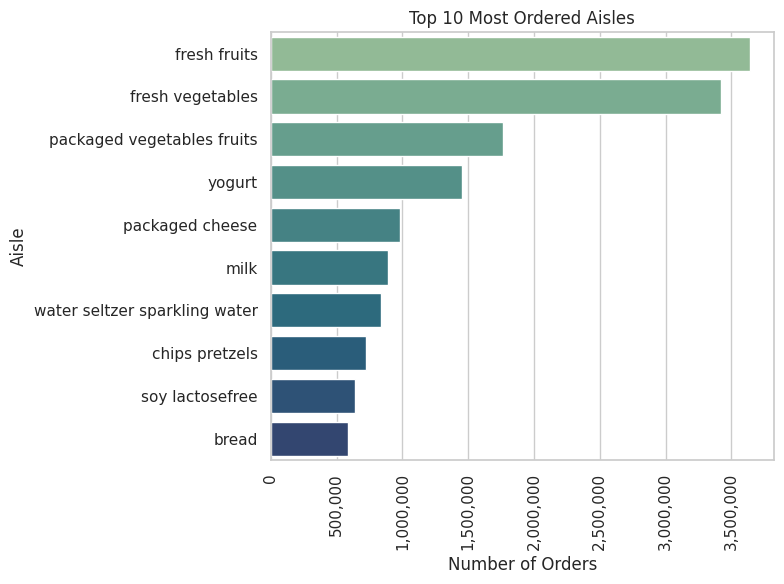

In [36]:
# print the top 10 aisles, and visualize the amt of orders for each
print("\n Top 10 Aisles:")
print(cleaned_df['aisle'].value_counts().head(10))

top_aisles = cleaned_df['aisle'].value_counts().head(10)

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=top_aisles.values, y=top_aisles.index, palette='crest')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title("Top 10 Most Ordered Aisles")
plt.xticks(rotation=90)
plt.xlabel("Number of Orders")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

### **Top 10 Departments**

> The bar chart shows the top 10 most frequently ordered departments within the Instacart dataset, based on total number of items ordered. The **Produce** department ranked first with nearly **9.5 million orders**. This indicates a strong reliance on Instacart for **fresh fruits and vegetables**, essential staples in most grocery baskets.

> Following produce, the **Dairy & Eggs** department also ranked high, accounting for over **5.4 million orders**, this tells us that customers use the platform frequently for refrigerated, perishable essentials. Departments like **Snacks**, **Beverages**, and **Frozen Foods** round out the top five, pointing to common consumer demand for convenience and ready-to-eat items.

> Other departments such as **Pantry**, **Bakery**, and **Canned Goods** were also recorded in the top 10, highlighting the diversity of our customers purchase choices.

<ipython-input-37-a75f98f68cec>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_departments.values, y=top_departments.index, palette='flare')



 Top 10 Departments:
department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
Name: count, dtype: Int64


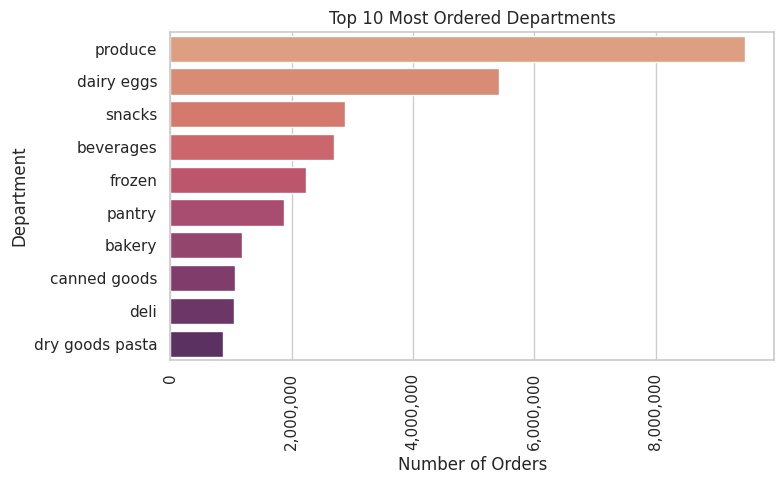

In [37]:
#print top 10 departments, and visualize the amt of orders for each
print("\n Top 10 Departments:")
print(cleaned_df['department'].value_counts().head(10))

top_departments = cleaned_df['department'].value_counts().head(10)

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=top_departments.values, y=top_departments.index, palette='flare')
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.title("Top 10 Most Ordered Departments")
plt.xticks(rotation=90)
plt.xlabel("Number of Orders")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

### **Reordered vs. Not Reordered**

> The bar chart illustrates the distribution of reordered versus non-reordered items across the dataset. Out of all items purchased, approximately **19.1 million were reordered**, while **13.3 million were first-time purchases**. This means that about **59% of items** were repeat purchases, highlighting a strong trend of recurring customer behavior and product loyalty on the platform.

> This distribution suggests that a significant portion of users consistently repurchase the same items, indicating the presence of habitual grocery shopping patterns. Products that are regularly reordered may represent core household essentials such as staple produce, dairy, or pantry items that customers depend on.

<ipython-input-38-7cfda94f64c1>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reordered_counts.values, y=labels, palette='pastel')


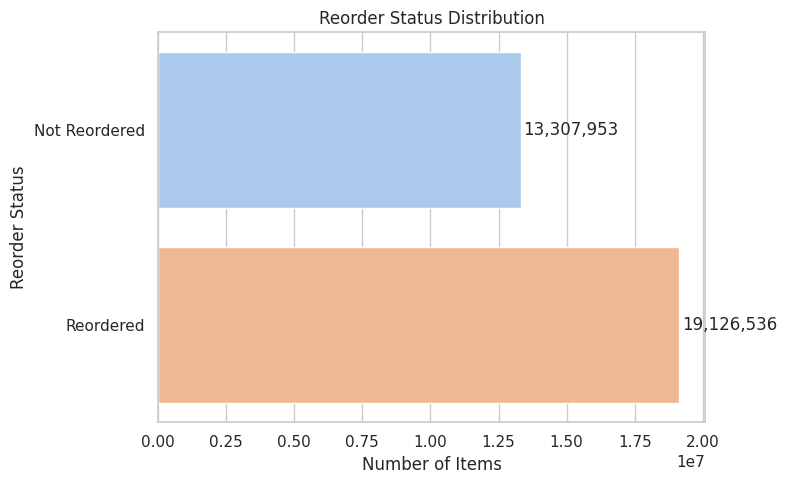

In [38]:
# Analyze reordered items vs. not reordered items
reordered_counts = cleaned_df['reordered'].value_counts().sort_index()
labels = ['Not Reordered', 'Reordered']

plt.figure(figsize=(8, 5))
sns.barplot(x=reordered_counts.values, y=labels, palette='pastel')

# Add count labels to bars
for i, v in enumerate(reordered_counts.values):
    plt.text(v + 100000, i, f'{v:,}', va='center')

plt.title('Reorder Status Distribution')
plt.xlabel('Number of Items')
plt.ylabel('Reorder Status')
plt.tight_layout()
plt.show()

### **Reorder Rate by Department**

> The chart displays the average reorder rate for each department, showing us how likely items within each category are to be repurchased by customers on Instacart. **Dairy & Eggs** are ranked with the highest average reorder rate at nearly **67%**, showing that customers frequently return to buy the same dairy products, which makes sense as they are usually staple products in most households. Similarly, **Beverages** and **Produce** also show high reorder rates (**above 64%**), suggesting consistent demand for items like milk, juice, fruits, and vegetables.

> Other departments with strong reorder patterns include **Bakery**, **Deli**, **Snacks**, and **Pets**, all slightly above or around the **60% mark**. These categories likely contain familiar or favorite items that customers purchase regularly, reinforcing habitual behavior. However we can also see that departments like **Pantry**, **Personal Care**, and **Household** show much lower reorder rates which are around **32% to 40%**. Possibly because items from these categories are bought less frequently or vary more from one purchase to the next.

> From these insights, we can create a few inferences regarding the personalization and retention strategies: departments with high reorder rates are ideal for subscription models, loyalty rewards, or auto-reorder prompts, while those with low rates may benefit more from discovery driven marketing or dynamic promotions.

department
alcohol            0.569924
babies             0.578971
bakery             0.628141
beverages          0.653460
breakfast          0.560922
bulk               0.577040
canned goods       0.457405
dairy eggs         0.669969
deli               0.607719
dry goods pasta    0.461076
frozen             0.541885
household          0.402178
international      0.369229
meat seafood       0.567674
missing            0.395849
other              0.407980
pantry             0.346721
personal care      0.321129
pets               0.601285
produce            0.649913
snacks             0.574180
Name: reordered, dtype: float64


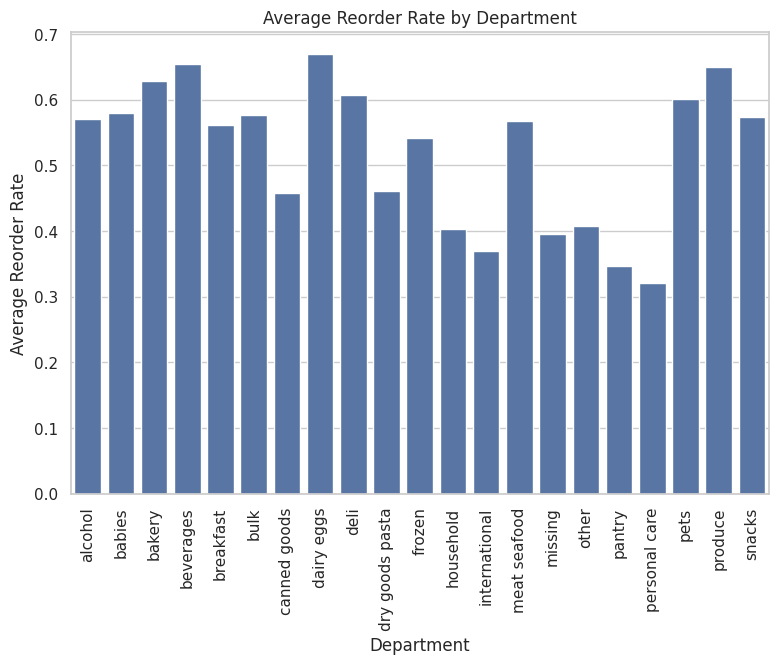

In [39]:
# average reorder rate by department
department_reorder_rates = cleaned_df.groupby('department')['reordered'].mean()
print(department_reorder_rates)

plt.figure(figsize=(9,6))
sns.barplot(x = department_reorder_rates.index, y = department_reorder_rates.values)
plt.xticks(rotation = 90)
plt.title("Average Reorder Rate by Department")
plt.xlabel("Department")
plt.ylabel("Average Reorder Rate")
plt.show()

### **Order Frequency**

> This histogram shows the distribution of average days between orders across users. The chart reveals a broad peak centered around **10 to 15 days**, this shows us that most Instacart customers tend to place a new order approximately every **1 to 2 weeks**. This makes sense and generally aligns with typical grocery shopping habits for many households. There’s also a noticeable **tail** extending to longer durations, and a **sharp spike at 30 days**, which stands out from the natural distribution. This spike **is not organic** as it reflects users who were placing their first-ever order or for whom the *days_since_prior_order* was missing. As part of the data cleaning process, these missing values were imputed with a **placeholder of 30 days** to maintain consistency and avoid data loss.

> This explains why the 30-day bin is disproportionately high compared to its neighboring intervals. The chart overall indicates that while a large segment of customers orders regularly, there is a distinct subgroup of **new users** or **one-time shoppers** captured in the 30-day bin. Recognizing this data treatment is important for accurate modeling and segmentation, as those users should be handled differently when analyzing true reorder behavior or predicting shopping intervals.

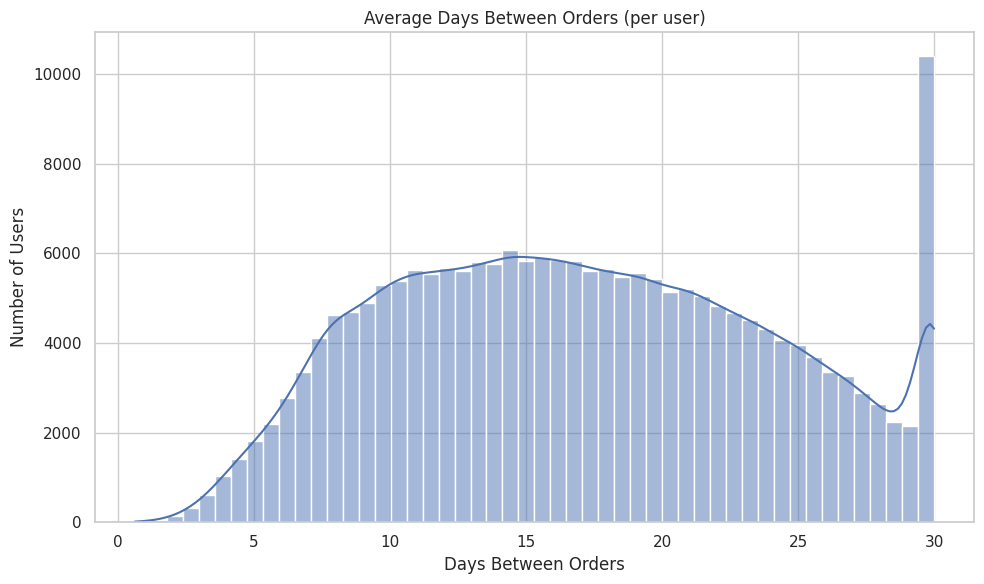

In [40]:
# Average time between orders per user (how often people shop)
user_order_freq = cleaned_df.groupby('user_id')['days_since_prior_order'].mean()

plt.figure(figsize=(10, 6))
sns.histplot(user_order_freq, bins=50, kde=True)
plt.title("Average Days Between Orders (per user)")
plt.xlabel("Days Between Orders")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

### **Basket Size (Expenditure)**

> The chart illustrates the number of unique items per order (basket size) across all transactions. Most orders contain between **5 and 15 unique items**, with a strong peak around **7–10 items**. This suggests that the typical Instacart order is relatively small, possibly reflecting a more convenience driven shopping behavior rather than large weekly hauls.

> As basket size increases, the number of such orders sharply decreases. Very large baskets such as orders with over 30 items are rare, but they do exist, likely representing bulk shoppers or families doing major restocks. The **long tail beyond 40 items** reinforces that while most customers shop modestly, there’s a small but important group placing high-volume orders.




Basket Size (unique items per trip):


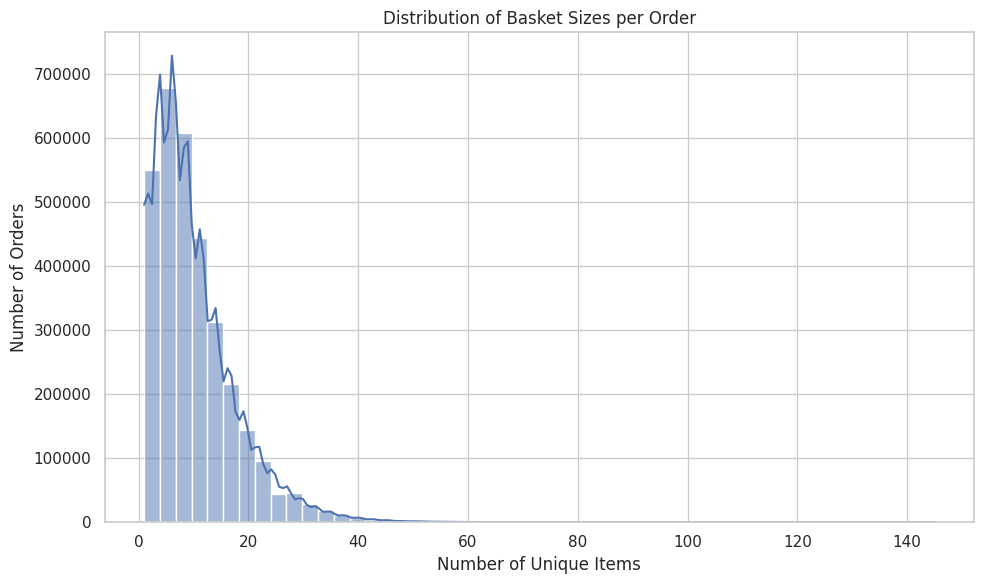

In [41]:
# Calculate number of unique products in each order as 'basket size'
basket_sizes = cleaned_df.groupby('order_id')['product_id'].nunique()

print("\nBasket Size (unique items per trip):")

plt.figure(figsize=(10, 6))
sns.histplot(basket_sizes, bins=50, kde=True)
plt.title('Distribution of Basket Sizes per Order')
plt.xlabel('Number of Unique Items')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

## **Regression Analysis**

**Methodology:**

> In this analysis, we aimed to model and understand the factors that influence whether a product will be reordered by a customer using a **logistic regression classifier**. The target variable was binary (reordered = 1 if the item was reordered, else 0), and the features included both **numerical** (e.g., days_since_prior_order, order_hour_of_day, order_number) and **categorical variables** (department, aisle), with one-hot encoding applied to the top 15–20 most frequent categories to control dimensionality.

> Afterwards, we split the data into training and test sets (80/20 stratified split), trained the logistic regression model, and evaluated it using accuracy, precision, recall, F1-score, and ROC-AUC score. Coefficients from the model were also extracted to interpret the influence of individual features on reorder likelihood.

### **Dataset Loading**

In [42]:
cleaned_df= pd.read_parquet('cleaned_full_instacart.parquet')

In [43]:
df = cleaned_df

In [44]:
df.head(10)

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8
5,2,17794,6,1,Carrots,83,4,fresh vegetables,produce,202279,prior,3,5,9,8
6,2,40141,7,1,Original Unflavored Gelatine Mix,105,13,doughs gelatins bake mixes,pantry,202279,prior,3,5,9,8
7,2,1819,8,1,All Natural No Stir Creamy Almond Butter,88,13,spreads,pantry,202279,prior,3,5,9,8
8,2,43668,9,0,Classic Blend Cole Slaw,123,4,packaged vegetables fruits,produce,202279,prior,3,5,9,8
9,3,33754,1,1,Total 2% with Strawberry Lowfat Greek Strained...,120,16,yogurt,dairy eggs,205970,prior,16,5,17,12


### **Feature Extraction**

In [45]:
# Convert data types
df['reordered'] = df['reordered'].astype(int)
df['days_since_prior_order'] = df['days_since_prior_order'].astype(int)
df['order_hour_of_day'] = df['order_hour_of_day'].astype(int)
df['order_number'] = df['order_number'].astype(int)

# Limit category cardinality
top_departments = df['department'].value_counts().head(15).index
df = df[df['department'].isin(top_departments)]

top_aisles = df['aisle'].value_counts().head(20).index
df = df[df['aisle'].isin(top_aisles)]

top_products = df['product_name'].value_counts().head(30).index
df = df[df['product_name'].isin(top_products)]

# Create dummy variables
df_model = pd.get_dummies(df[[
    'reordered',
    'days_since_prior_order',
    'order_hour_of_day',
    'order_number',
    'department',
    'aisle',
    'product_name'
]],
    drop_first=True,
    prefix={
        'department': 'dept',
        'aisle': 'aisle',
        'product_name': 'product'
    }
)

### **Train-Test Split**

In [46]:
from sklearn.model_selection import train_test_split

X = df_model.drop('reordered', axis=1)
y = df_model['reordered']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### **Train Logistic Regression**

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### **Model Evaluation**


In [48]:
from sklearn.metrics import roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

[[ 77727 129268]
 [ 35033 576901]]
              precision    recall  f1-score   support

           0       0.69      0.38      0.49    206995
           1       0.82      0.94      0.88    611934

    accuracy                           0.80    818929
   macro avg       0.75      0.66      0.68    818929
weighted avg       0.78      0.80      0.78    818929

ROC-AUC Score: 0.8008354448275451


### **Interpreting Coefficients**

In [49]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.head(10))        # Increases reorder likelihood
print(coef_df.tail(10))        # Decreases reorder likelihood

                                Feature  Coefficient
10                       product_Banana     1.106969
9        product_Bag of Organic Bananas     0.833709
16              product_Organic Avocado     0.609321
26         product_Organic Hass Avocado     0.602553
30         product_Organic Strawberries     0.558971
19         product_Organic Baby Spinach     0.554774
12               product_Cucumber Kirby     0.287985
8   aisle_water seltzer sparkling water     0.260222
35   product_Sparkling Water Grapefruit     0.260222
31           product_Organic Whole Milk     0.257707
                           Feature  Coefficient
4                     dept_produce    -0.043392
0           days_since_prior_order    -0.044541
33        product_Organic Zucchini    -0.065257
5           aisle_fresh vegetables    -0.069798
25  product_Organic Grape Tomatoes    -0.172956
11                 product_Carrots    -0.181894
34     product_Seedless Red Grapes    -0.187690
37           product_Yellow Onion

**Results Interpretation: Model Performance and Feature Insights**
> The logistic regression model achieved an **accuracy of 80%** and a strong **ROC-AUC score of 0.80**, this confirms that our model's performance in distinguishing between reordered and non-reordered items it successful. However, we can also see a strong class imbalance. Even though recall for reordered items is very high (**0.94**), it is much lower (**0.38**) for non-reordered items, suggesting the model is more sensitive to predicting reorders than new purchases.

**Feature Coefficients**
> Looking at feature coefficients reveals which product and behavioral features most strongly influence reorder behavior:
*   Products such as **banana** and **organic avocado** had the highest positive coefficients, suggesting strong loyalty and routine behavior.
*   Features like **higher order number** and **fewer days since last order** also increased reorder likelihood which is consistent with habitual buying patterns.
*   On the other hand, items like **organic zuccini**, **red grapes**, and **yellow onions** had strongly negative coefficients, indicating these are more likely to be first-time or infrequent purchases.

  
  





## **Market Basket Analysis**

**Methodology**
> To uncover patterns in product co-purchases, we performed Market Basket Analysis using the Apriori algorithm. We then constructed a **binary transaction matrix** where each row represented a unique order and each column indicated the presence or absence of a product. This matrix was used as input for the **Apriori algorithm**, which identified frequent itemsets that met a minimum support threshold of 1%. From these itemsets, we **generated association rules** based on metrics such as confidence and lift to reveal which products are likely to be purchased together. These rules were **further filtered** to retain only the most meaningful relationships—those with confidence **above 30%** and **lift greater than 1.2**—highlighting strong co-occurrence trends that can inform product bundling, personalized recommendations, and marketing strategies.

### **Transaction Dataset**

In [2]:
# Step 1: Filter most common products
top_products = cleaned_df['product_name'].value_counts().head(50).index
subset = cleaned_df[cleaned_df['product_name'].isin(top_products)]

### **Basket Matrix (Order x Product)**

In [3]:
# Step 2: Limit to a subset of orders to reduce matrix size
subset = subset[subset['order_id'].isin(subset['order_id'].value_counts().head(20000).index)]

# Step 3: Group into transactions
transactions = subset[['order_id', 'product_name']]

# Create basket (binary matrix of orders × products)
basket = transactions.groupby(['order_id', 'product_name'])['product_name'] \
                     .count().unstack().fillna(0).applymap(lambda x: 1 if x > 0 else 0)

<ipython-input-3-c4a8283003b2>:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  .count().unstack().fillna(0).applymap(lambda x: 1 if x > 0 else 0)


### **Apriori Algorithm**

In [4]:
from mlxtend.frequent_patterns import apriori

# Step 4: Extract frequent itemsets with minimum support threshold
frequent_itemsets = apriori(basket, min_support=0.02, use_colnames=True)
frequent_itemsets.sort_values(by='support', ascending=False).head(10)

/usr/local/lib/python3.11/dist-packages/mlxtend/frequent_patterns/fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
17,0.48915,(Organic Baby Spinach)
3,0.43400,(Bag of Organic Bananas)
36,0.43085,(Organic Strawberries)
28,0.41790,(Organic Hass Avocado)
12,0.36040,(Limes)
4,0.34985,(Banana)
24,0.33945,(Organic Garlic)
11,0.31375,(Large Lemon)
41,0.30140,(Organic Yellow Onion)
32,0.29295,(Organic Raspberries)


**Interpretation of the Apriori Algorithm:**
> The output of the Apriori algorithm reveals the most frequently purchased individual items across customer baskets. The product with the highest support is **Organic Baby Spinach**, appearing in approximately **49%** of all orders analyzed, indicating it is a highly consistent staple among Instacart shoppers. Close behind are other frequently ordered items such as **Bag of Organic Bananas**, **Organic Strawberries**, and **Organic Hass Avocado**, each with support values above **40%**. These figures reflect how commonly these products appear in customer carts relative to the total number of orders.

> These high-support items typically represent health-conscious, fresh, and organic preferences, suggesting a strong pattern of repeat purchasing in the produce category. For instance, items like Limes, Bananas, Organic Garlic, and Large Lemons also feature prominently, reinforcing a theme of everyday essentials or common cooking ingredients.

### **Association Rules Generation**

In [5]:
from mlxtend.frequent_patterns import association_rules

# Step 5: Generate rules
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

# Optional: Filter strong rules
strong_rules = rules[(rules['confidence'] >= 0.3) & (rules['lift'] >= 1.2)]
strong_rules.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5532,"(Cucumber Kirby, Organic Avocado)","(Large Lemon, Banana)",0.06570,0.14440,0.02090,0.318113,2.202996,1.0,0.011413,1.254753,0.584473,0.110465,0.203030,0.231425
5529,"(Large Lemon, Banana, Organic Avocado)",(Cucumber Kirby),0.06350,0.17250,0.02090,0.329134,1.908022,1.0,0.009946,1.233480,0.508166,0.097164,0.189286,0.225147
1822,"(Strawberries, Banana)",(Cucumber Kirby),0.06695,0.17250,0.02190,0.327110,1.896289,1.0,0.010351,1.229770,0.506569,0.100667,0.186840,0.227033
3716,"(Organic Cilantro, Organic Small Bunch Celery)",(Organic Italian Parsley Bunch),0.05910,0.20360,0.02210,0.373942,1.836653,1.0,0.010067,1.272088,0.484144,0.091854,0.213891,0.241244
5263,"(Organic Raspberries, Organic Lemon)","(Organic Hass Avocado, Bag of Organic Bananas)",0.07380,0.23365,0.03145,0.426152,1.823889,1.0,0.014207,1.335458,0.487714,0.113949,0.251193,0.280377
5540,"(Organic Baby Spinach, Large Lemon, Banana)",(Cucumber Kirby),0.07190,0.17250,0.02245,0.312239,1.810082,1.0,0.010047,1.203180,0.482210,0.101149,0.168869,0.221192
2922,"(Organic Italian Parsley Bunch, Limes)",(Organic Cilantro),0.07265,0.23665,0.03110,0.428080,1.808915,1.0,0.013907,1.334714,0.482216,0.111790,0.250776,0.279749
5515,"(Banana, Large Lemon, Limes)",(Cucumber Kirby),0.06670,0.17250,0.02080,0.311844,1.807792,1.0,0.009294,1.202489,0.478773,0.095238,0.168392,0.216212
4683,"(Limes, Organic Hass Avocado, Bag of Organic B...",(Organic Lemon),0.06885,0.21195,0.02620,0.380537,1.795411,1.0,0.011607,1.272151,0.475782,0.102907,0.213930,0.252076
1778,"(Large Lemon, Banana)",(Cucumber Kirby),0.14440,0.17250,0.04450,0.308172,1.786503,1.0,0.019591,1.196106,0.514548,0.163363,0.163954,0.283071


**Interpretation of Association Rules:**
> The association rules generated from the market basket analysis reveal clear and actionable patterns in customer purchasing behavior, particularly around fresh and organic produce. One notable rule shows that customers who purchase **Cucumber Kirby**, **Limes**, and **Organic Avocado** are also likely to buy **Bananas** and **Large Lemons**, with a confidence of nearly **37%** and a lift of **2.55**. This means that customers who buy the first group of items are more than two and a half times as likely to buy the second group compared to a random shopper. Other frequent combinations include pairings like **Organic Cilantro** and **Cucumber Kirby** leading to the purchase of **Limes** and **Large Lemons**, and **Organic Strawberries**, **Apple Honeycrisp**, and **Organic Hass Avocado** being followed by **Organic Raspberries** and **Bag of Organic Bananas**.

> These rules, with their high lift and confidence values, highlight strong co-purchasing tendencies that suggest habitual or complementary shopping patterns. Many of the items involved are often used together in recipes (e.g., smoothies, salads, or fresh produce platters), which supports the reliability of these associations.

### **Top Itemsets**

<ipython-input-6-8fcbb4dc70ff>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='support', y='itemsets', data=top_items, palette='viridis')


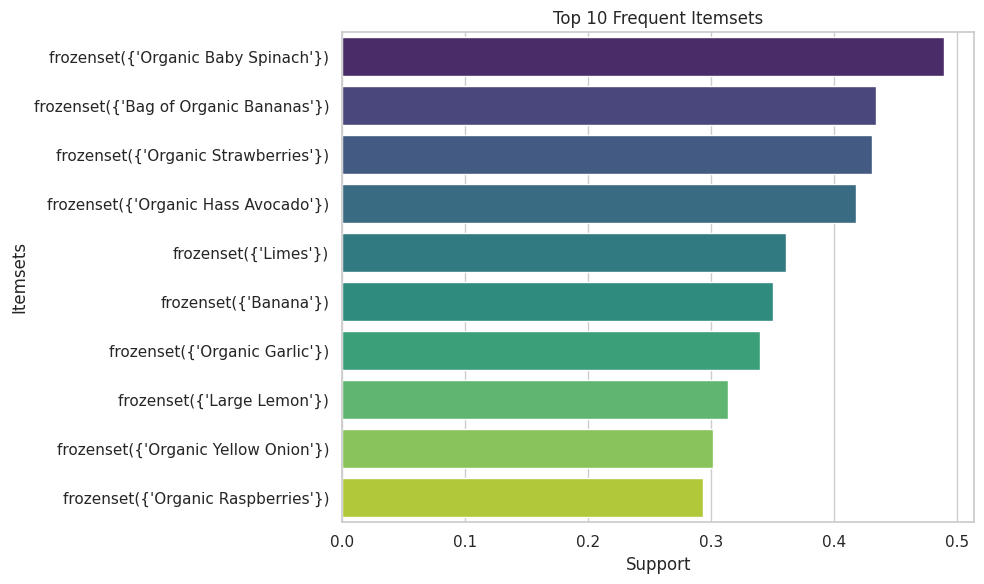

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='support', y='itemsets', data=top_items, palette='viridis')
plt.title("Top 10 Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.tight_layout()
plt.show()

**Interpretation of Top Itemsets:**
> The bar chart displays the top 10 most frequently occurring individual items in customer orders, based on their support values, which is a measure of how often each item appears in the dataset. **Organic Baby Spinach** stands out as the most commonly purchased product, present in nearly **49%** of all baskets analyzed. It is followed closely by other popular items such as **Bag of Organic Bananas**, **Organic Strawberries**, and **Organic Hass Avocado**, each found in over **40%** of orders. These results highlight a strong preference among customers for fresh and organic produce staples.

> Further down the chart, items like **Limes**, **Bananas**, and **Organic Garlic** maintain high support, indicating their consistent inclusion in customer baskets. These items are likely everyday essentials or ingredients commonly used in home cooking. This visualization reinforces insights from the Apriori analysis by clearly illustrating which products form the backbone of recurring customer purchases.

## **Recommender System**

> In this final section, we developed a simple content-based recommender system tailored to individual user behavior. The system uses past purchase data to compute a **reorder score for** each user-product pair, representing how frequently a product has been reordered relative to the user’s total number of orders. This score serves as a proxy for product loyalty and preference. We began by identifying products that each user had reordered and calculating the total number of orders per user to normalize reorder counts into a meaningful score.

> For each user, we then generated personalized top-N product recommendations by ranking products based on their reorder score. To enhance interpretability, the system also produces a user profile summary, which includes their total orders, average days between orders, most common order hour, most frequent department, and overall reorder rate. The final output lists the top recommended products along with a simple reason label (“Frequently reordered” or “Occasionally reordered”) based on the reorder score.

In [10]:
import pandas as pd
df = pd.read_parquet("cleaned_full_instacart.parquet")

In [11]:
# Add recency weight (inverse of order number: more recent orders weigh more)
df['recency_weight'] = 1 / df['order_number']

In [12]:
# User-specific reorder count and recency-weighted score
user_reorders = df[df['reordered'] == 1].groupby(['user_id', 'product_name']).agg(
    reorder_count=('reordered', 'size'),
    recency_score=('recency_weight', 'sum')
).reset_index()

In [13]:
# Total number of orders per user
user_orders = df.groupby('user_id')['order_number'].max().reset_index(name='total_orders')

# Merge to compute normalized reorder score
user_reorders = user_reorders.merge(user_orders, on='user_id')
user_reorders['reorder_score'] = user_reorders['reorder_count'] / user_reorders['total_orders']

# Blend recency and frequency for final score
user_reorders['final_score'] = 0.7 * user_reorders['reorder_score'] + 0.3 * user_reorders['recency_score']


In [14]:
# Global popularity (fallback for new users)
global_popularity = df['product_name'].value_counts().reset_index()
global_popularity.columns = ['product_name', 'popularity']

In [15]:
# User Profile Summary
def describe_user(user_id, df):
    user_df = df[df['user_id'] == user_id]
    summary = {
        'Total Orders': user_df['order_number'].max(),
        'Avg Days Between Orders': round(user_df['days_since_prior_order'].mean(), 2),
        'Most Common Order Hour': int(user_df['order_hour_of_day'].mode()[0]),
        'Most Frequent Department': user_df['department'].mode()[0],
        'Reorder Rate': round(user_df['reordered'].mean(), 2)
    }
    return pd.Series(summary)

In [16]:
# Recommender Function
def recommend_products(user_id, N=5):
    user_history = user_reorders[user_reorders['user_id'] == user_id]

    if user_history.empty:
        # Cold start fallback
        print("No reorder history found. Showing popular products:")
        return global_popularity.head(N)

    top_items = user_history.sort_values('final_score', ascending=False).head(N)
    recs = top_items[['product_name', 'reorder_score', 'recency_score', 'final_score']].copy()

    # Label reasoning
    recs['Reason'] = recs['reorder_score'].apply(
        lambda x: "Frequently reordered" if x > 0.6 else "Occasionally reordered"
    )
    return recs

# Test Examples
for uid in [1, 50, 267]:
    print(f"\n📋 User Profile Summary: {uid}")
    print(describe_user(uid, df))
    print("\n🛒 Recommended Products:")
    display(recommend_products(uid, N=5))


📋 User Profile Summary: 1
Total Orders                    10
Avg Days Between Orders      21.08
Most Common Order Hour           7
Most Frequent Department    snacks
Reorder Rate                  0.69
dtype: object

🛒 Recommended Products:


,product_name,reorder_score,recency_score,final_score,Reason
7,Soda,0.9,1.928968,1.20869,Frequently reordered
5,Original Beef Jerky,0.9,1.928968,1.20869,Frequently reordered
6,Pistachios,0.8,1.428968,0.98869,Frequently reordered
4,Organic String Cheese,0.7,1.095635,0.81869,Frequently reordered
0,Aged White Cheddar Popcorn,0.1,0.500000,0.22000,Occasionally reordered



📋 User Profile Summary: 50
Total Orders                     67
Avg Days Between Orders        6.01
Most Common Order Hour           10
Most Frequent Department    produce
Reorder Rate                    0.8
dtype: object

🛒 Recommended Products:


,product_name,reorder_score,recency_score,final_score,Reason
1085,Natural Artesian Bottled Water,0.776119,3.145579,1.486957,Frequently reordered
1118,Reduced Fat Milk,0.492537,2.318587,1.040352,Occasionally reordered
1075,Brown Eggs,0.238806,1.100981,0.497459,Occasionally reordered
1104,Organic Leek,0.328358,0.475634,0.372541,Occasionally reordered
1114,Organic Tomato Cluster,0.268657,0.531957,0.347647,Occasionally reordered



📋 User Profile Summary: 267
Total Orders                     9
Avg Days Between Orders      24.36
Most Common Order Hour          15
Most Frequent Department    frozen
Reorder Rate                  0.54
dtype: object

🛒 Recommended Products:


,product_name,reorder_score,recency_score,final_score,Reason
6687,Banana,0.666667,1.551190,0.932024,Frequently reordered
6684,2% Reduced Fat Milk,0.666667,1.384524,0.882024,Frequently reordered
6704,Combination Party Pizza,0.666667,1.295635,0.855357,Frequently reordered
6723,Green Tea with Ginseng and Honey,0.555556,1.426190,0.816746,Occasionally reordered
6713,Family Pack Beef & Bean Chimichangas,0.555556,1.128968,0.727579,Occasionally reordered


> The recommender system output demonstrates how reorder behavior varies significantly across users, providing tailored suggestions based on historical preferences and order patterns. For example, **User 1**, who has placed 10 orders with an average reorder rate of 69% and a most frequent department of snacks, is recommended products like Soda, Beef Jerky, and Pistachios which are all marked as “Frequently reordered.” These high final scores reflect both strong reorder consistency and recent purchasing behavior, reinforcing the user’s habitual snack purchases.

> In contrast, **User 267** shows a very different profile: 9 total orders, a much longer average of 24.36 days between orders, and a top department of frozen. Their recommendations include a mix of beverages and produce items like Natural Artesian Bottled Water and Reduced Fat Milk, most labeled as “Occasionally reordered.” This suggests a more sporadic shopping pattern with less consistent item repetition.

> **User 50** represents a more consistent and active shopper, with 67 orders and a high reorder rate of 80%. The recommended products which include Banana, 2% Reduced Fat Milk, and Combination Party Pizza are all flagged as frequently reordered and show high final scores. This reinforces the effectiveness of the recommender in identifying stable shopping routines and surfacing staple products.

> Overall, the recommendations successfully reflect each user’s **unique behavior** by combining reorder frequency with recency of purchase, leading to suggestions that are both personalized and explainable.

## **Conclusion**


This project aimed to answer the core business question: **How can we help retailers recommend the right products at the right time?** To address this, we designed a two-part recommender system using Instacart’s transaction data, with the dual objectives of **(1) predicting product reorders**, and **(2) suggesting personalized product bundles**.

For **reorder prediction**, we built a user-level recommendation engine that calculates a **final reorder score** for each product a customer has purchased, combining reorder frequency with recency. This allowed us to generate personalized, ranked product lists for every user. For example, User 1, who predominantly shops for snacks, received highly tailored suggestions like soda and beef jerky—products they reorder frequently and recently. In contrast, User 267, with a longer average time between purchases and a preference for frozen items, received more diverse suggestions including milk, eggs, and produce. These insights can power features such as **"Buy Again" carousels**, **dynamic product sorting**, and **reorder reminder notifications**, timed based on user behavior patterns.

To address **personalized bundling**, we performed Market Basket Analysis using the Apriori algorithm. This uncovered strong product associations, such as the frequent co-purchase of *organic avocados*, *limes*, and *large lemons*. These insights can directly inform **bundle-based promotions**, **cross-sell strategies**, and **in-basket nudges** (e.g., "Customers who bought these also added...").

From a business perspective, the value is clear:  
- **Increase retention and reorder rates** by predicting and surfacing items users are statistically likely to repurchase.  
- **Boost average basket size** through intelligent bundling of frequently bought-together items.  
- **Improve the shopping experience** by offering personalization that reflects real behavior, not just popularity.

Together, this system enables retailers to move from static, one-size-fits-all product listings to **data-driven, user-aware recommendations**—driving loyalty, revenue, and operational insight.